# Parameters

In [7]:
from pathlib import Path
import sys 

repo_root = Path.cwd().resolve()
if repo_root.name == "notebooks":
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from common.utils.parameters import (
    mcwf_dt_from_scales,
    omega_c,
    scaled_N_Gamma,
)
from common.utils.phases import default_three_phase_protocol
from post_analysis import compute_mfe_residuals
from parser.moments import MomentSeries, SimulationMetadata


%reload_ext autoreload
%autoreload 2

output_dir = Path("../output")

### Parameters

In [2]:
# common fixed
Gamma = 1; dt = 1e-2; num_snapshots=100
# param
dN = 0
Ni = [15,15]
omega_i = [0.7]
ntraj = 100
# Model and parameters
Omega_factor = 0.1
Omega0 = scaled_N_Gamma(Omega_factor, sum(Ni), Gamma)
delta_factor = 0.02
delta0 = scaled_N_Gamma(delta_factor, sum(Ni), Gamma)
dt = mcwf_dt_from_scales(Omega0, delta0, sum(Ni), Gamma)

# protocol durations
durations = (20.0, 20.0, 10.0)

phase_protocol = default_three_phase_protocol(
    durations=durations,
    delta0=delta0,
    Omega0=Omega0,
)
phase_protocol_ramp = default_three_phase_protocol(
    durations=durations,
    delta0=delta0,
    Omega0=Omega0,
    ramp_durations=(10.0, 10.0, 0.0),
    ramp_segment_counts=(9, 9, 0),
)

simulation_metadata = SimulationMetadata(
    Ni=tuple(Ni),
    omega_i=tuple(omega_i),
    Gamma=Gamma,
    phase_protocol=phase_protocol,
)
simulation_metadata_ramp = SimulationMetadata(
    Ni=tuple(Ni),
    omega_i=tuple(omega_i),
    Gamma=Gamma,
    phase_protocol=phase_protocol_ramp,
)

Omega_c = omega_c(sum(Ni) // 2, Gamma)
print(f"Omega0 = {Omega0}")
print(f"Omega/Omega_c ratio = {Omega0 / Omega_c}")
print(f"delta0 = {delta0}")
print(f"dt = {dt}")


Omega0 = 3.0
Omega/Omega_c ratio = 0.4
delta0 = 0.6
dt = 0.0033333333333333335


### Monte-Carlo Wave Function

In [3]:
from parser.mcwf import MCWFSolverParameters
from solvers.mcwf.ensamble_sim import run_trajectory_ensemble
from solvers.mcwf.j_moments import compute_mcwf_j_moments

# moment initialization
mcwf_moments = MomentSeries(
    num_snapshots=num_snapshots,
    metadata=simulation_metadata,
)
mcwf_moments_ramp = MomentSeries(
    num_snapshots=num_snapshots,
    metadata=simulation_metadata_ramp,
)

# Define method parameters and simulate using Monte-Carlo wave function method
mcwf_parameters = MCWFSolverParameters(
    Ni=simulation_metadata.Ni,
    omega_i=simulation_metadata.omega_groups,
    Gamma=simulation_metadata.Gamma,
    phase_protocol=simulation_metadata.phase_protocol,
    dN=dN,
    sector_distribution="binomial",
    dt=dt,
    shifted_jump_operator=True,
)
mcwf_parameters_ramp = MCWFSolverParameters(
    Ni=simulation_metadata_ramp.Ni,
    omega_i=simulation_metadata_ramp.omega_groups,
    Gamma=simulation_metadata_ramp.Gamma,
    phase_protocol=simulation_metadata_ramp.phase_protocol,
    dN=dN,
    sector_distribution="binomial",
    dt=dt,
    shifted_jump_operator=True,
)


mcwf_ensemble = run_trajectory_ensemble(
    mcwf_parameters,
    t_eval=mcwf_moments.t,
    seed=1234,
    ntraj=ntraj,
    n_processes=-1,
    )
mcwf_ensemble_ramp = run_trajectory_ensemble(
    mcwf_parameters_ramp,
    t_eval=mcwf_moments_ramp.t,
    seed=1234,
    ntraj=ntraj,
    n_processes=-1,
    )

# compute moments
mcwf_moments.J = compute_mcwf_j_moments(
    mcwf_ensemble,
    n_processes=-1,
)
mcwf_moments_ramp.J = compute_mcwf_j_moments(
    mcwf_ensemble_ramp,
    n_processes=-1,
)

# mfe residuals
mcwf_moments.mfe_residuals = compute_mfe_residuals(
    mcwf_moments.J,
    metadata=mcwf_moments.metadata,
)
mcwf_moments_ramp.mfe_residuals = compute_mfe_residuals(
    mcwf_moments_ramp.J,
    metadata=mcwf_moments_ramp.metadata,
)

/Users/ashar/.pyenv/versions/cavity-OAT_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
simulate trajectories: 100%|██████████| 100/100 [00:01<00:00, 50.64it/s]


Simulation step summary (avg per trajectory): total steps=15074.46, steps without precompute=126.44


simulate trajectories: 100%|██████████| 100/100 [00:01<00:00, 50.76it/s]


Simulation step summary (avg per trajectory): total steps=15075.44, steps without precompute=134.44


compute_mcwf_j_moments: 100%|██████████| 100/100 [00:01<00:00, 71.13it/s]


### Plotting

Residual L1 norm
Phase 1 - end: 2.144e-02, min: 0.000e+00
Phase 2 - end: 1.857e-03, min: 1.520e-03
Phase 3 - end: 7.058e-09, min: 7.058e-09
Residual L1 norm
Phase 1 - end: 2.943e-03, min: 0.000e+00
Phase 2 - end: 4.807e-03, min: 9.384e-04
Phase 3 - end: 1.110e-06, min: 1.110e-06


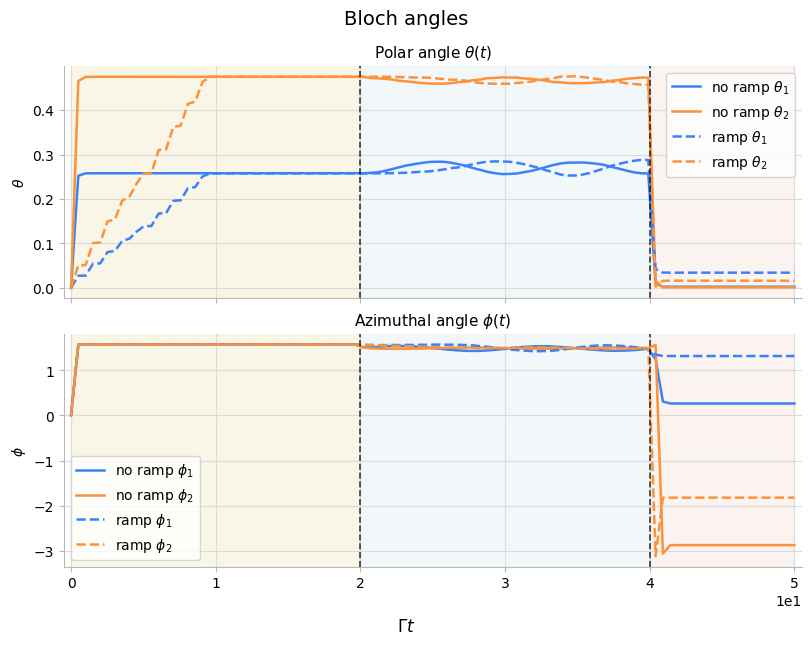

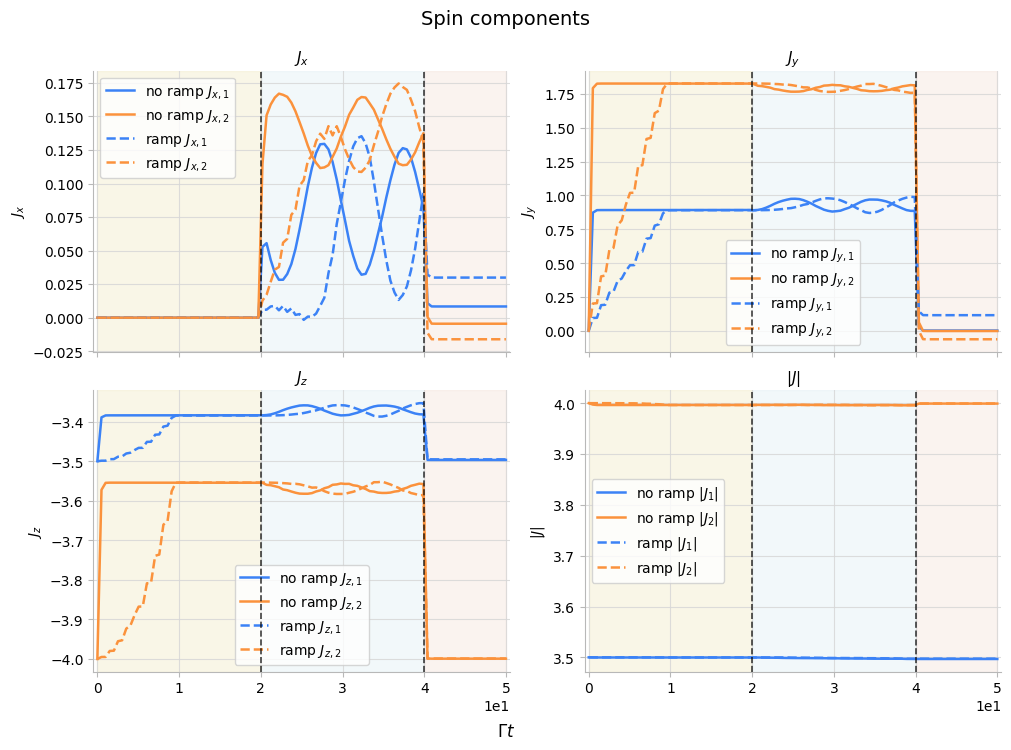

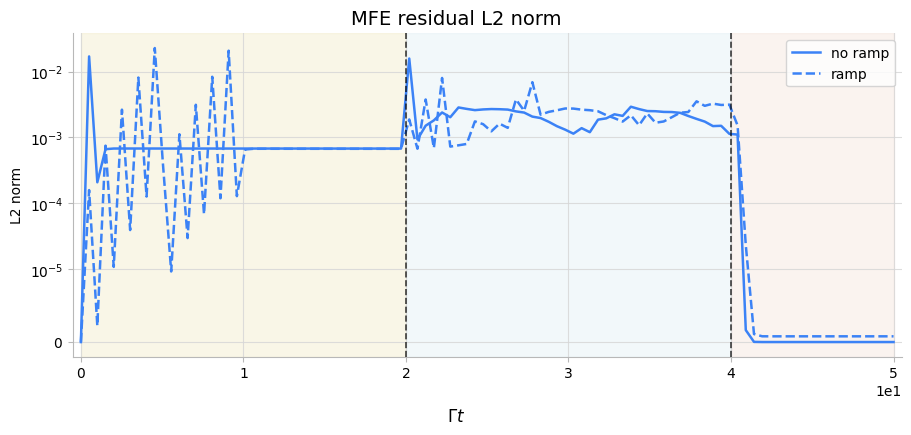

In [8]:
from common.plotting import (
    plot_bloch_angles,
    plot_spin_components,
    plot_mfe_residuals
)

# Plot spin angles

fig, axes = plot_bloch_angles(
    angle_series=mcwf_moments.J,
    phase_protocol=mcwf_moments.metadata.phase_protocol,
    label="no ramp",
    colour_family_index=None,
    shade_index=2,
    linestyle="-",

)
fig, axes = plot_bloch_angles(
    angle_series=mcwf_moments_ramp.J,
    phase_protocol=mcwf_moments_ramp.metadata.phase_protocol,
    label="ramp",
    colour_family_index=None,
    shade_index=2,
    linestyle="--",
    axes=axes,
    output_path=f"{output_dir}/parameter_ramp/angles_mcwf",
)

# Plot spin components
fig, axes = plot_spin_components(
    spin_series=mcwf_moments.J,
    normalized=False,
    phase_protocol=mcwf_moments.metadata.phase_protocol,
    label="no ramp",
    colour_family_index=None,
    shade_index=2,
    linestyle="-",
)
fig, axes = plot_spin_components(
    spin_series=mcwf_moments_ramp.J,
    normalized=False,
    phase_protocol=mcwf_moments_ramp.metadata.phase_protocol,
    label="ramp",
    colour_family_index=None,
    shade_index=2,
    linestyle="--",
    axes=axes,
    output_path=f"{output_dir}/parameter_ramp/spins_mcwf",
)


# plot mfe residuals
fig, axes = plot_mfe_residuals(
    mcwf_moments.mfe_residuals,
    phase_protocol=mcwf_moments.metadata.phase_protocol,
    show_components=False,
    label="no ramp",
    colour_family_index=None,
    shade_index=2,
    linestyle="-",
)
fig, axes = plot_mfe_residuals(
    mcwf_moments_ramp.mfe_residuals,
    phase_protocol=mcwf_moments_ramp.metadata.phase_protocol,
    show_components=False,
    label="ramp",
    colour_family_index=None,
    shade_index=2,
    linestyle="--",
    axes=axes,
    output_path=f"{output_dir}/parameter_ramp/mfe_residuals_mcwf",
)